# Inference: 46-Class Fruit Classifier

Evaluate the trained model on the test set with confusion matrix and classification report.

In [1]:
import torch
import timm
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Setup Model
NUM_CLASSES = 46
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load("fruit_classifier_46cls_b0.pth", map_location=device))
model = model.to(device)
model.eval()

# 2. Setup Test Data
config = timm.data.resolve_model_data_config(model)
test_transform = timm.data.create_transform(**config, is_training=False)
test_ds = datasets.ImageFolder("PrepData/Test", transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f"Test samples: {len(test_ds)}")
print(f"Classes: {test_ds.classes}")

Test samples: 5077
Classes: ['Chinese_chestnut', 'Dangshan_Pear', 'Hami_melon', 'almond', 'annona_muricata', 'apple', 'apricot', 'artocarpus_heterophyllus', 'avocado', 'banana', 'bayberry', 'bergamot_pear', 'black_currant', 'black_grape', 'blood_orange', 'blueberry', 'breadfruit', 'candied_date', 'carambola', 'cashew_nut', 'cherry', 'cherry_tomato', 'citrus', 'coconut', 'crown_pear', 'dekopon', 'diospyros_lotus', 'durian', 'fig', 'flat_peach', 'gandaria', 'ginseng_fruit', 'golden_melon', 'grape', 'grape_white', 'grapefruit', 'green_apple', 'green_dates', 'guava', 'hawthorn', 'hazelnut', 'hickory', 'honey_dew_melon', 'housi_pear', 'juicy_peach', 'jujube']


In [2]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Classification Report
target_names = test_ds.classes
print("Test Set Performance:")
print(classification_report(all_labels, all_preds, target_names=target_names))

Test Set Performance:
                          precision    recall  f1-score   support

        Chinese_chestnut       0.74      0.70      0.72       150
           Dangshan_Pear       0.45      0.38      0.42        39
              Hami_melon       0.79      0.45      0.57        51
                  almond       0.77      0.83      0.80       102
         annona_muricata       0.73      0.78      0.76       190
                   apple       0.81      0.73      0.76       161
                 apricot       0.71      0.56      0.63       102
artocarpus_heterophyllus       0.68      0.72      0.70       140
                 avocado       0.71      0.75      0.73       102
                  banana       0.62      0.76      0.69       174
                bayberry       0.73      0.67      0.70       110
           bergamot_pear       0.67      0.71      0.69        79
           black_currant       0.67      0.89      0.77        83
             black_grape       0.64      0.61      0.

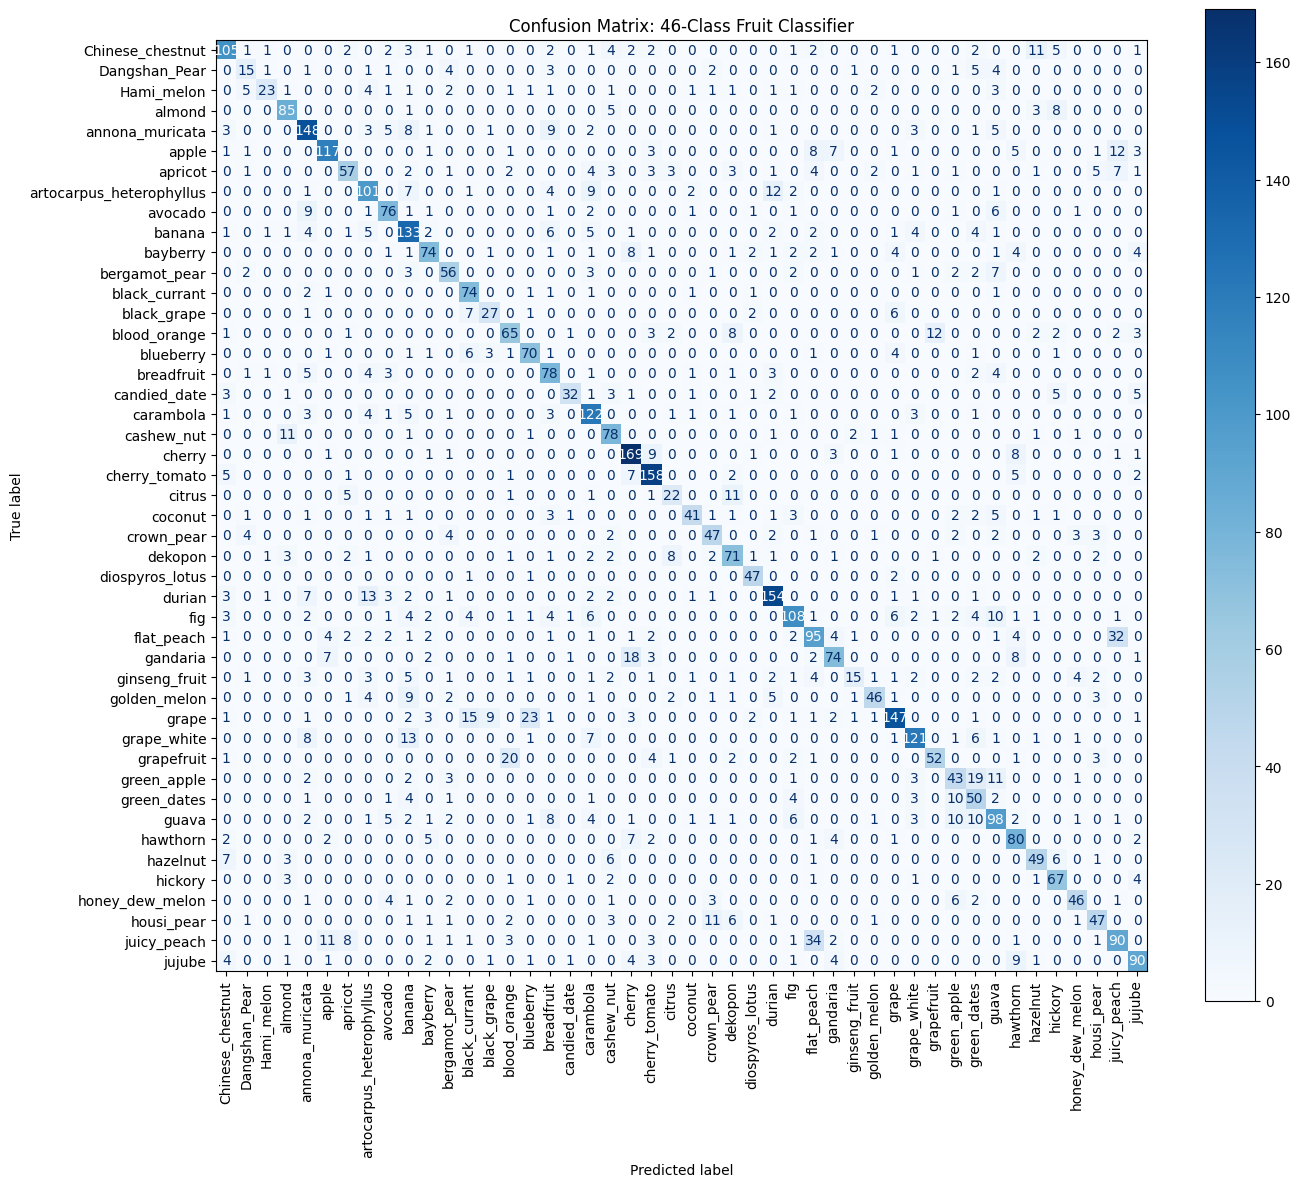

In [3]:
# 4. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=90)
plt.title("Confusion Matrix: 46-Class Fruit Classifier")
plt.tight_layout()
plt.show()